# Spatial Modeling with Spatio-Flux

This notebook demonstrates how to load the [spatio-flux](https://github.com/vivarium-collective/spatio-flux) library into Vivarium to build spatial, multi-agent simulations.

Spatio-flux provides:
- Custom types for concentrations, particles, and spatial fields
- Processes for diffusion-advection, Brownian movement, dynamic FBA, and more
- Configuration builders for common spatial simulation patterns

## Prerequisites

Install spatio-flux:
```bash
pip install spatio-flux
```

## 1. Load the spatio-flux Core

The `register_types` function from spatio-flux registers all custom types and processes into the Core.

In [1]:
from vivarium import Vivarium
from spatio_flux import register_types

# Create a Vivarium with spatio-flux types and processes
v = Vivarium(register=register_types)
print(v)

module `wholecell.utils._netflow.nf_cplex` not found during dynamic import
module `wholecell.utils.toya` not found during dynamic import
module `genEcoli` not found during dynamic import
Vivarium(time=0.0, state_keys=['global_time', 'emitter'])


## 2. Browse available types

Spatio-flux registers types like `concentration`, `mass`, `position`, `particle`, `fields`, and more.

In [2]:
# List all registered types
v.types(as_dataframe=True)

,Type
0,node
1,atom
2,empty
3,union
4,tuple
5,boolean
6,or
7,and
8,xor
9,number


In [3]:
# List all registered processes
v.processes(as_dataframe=True)

,Process
0,edge
1,process_bigraph.composite.Composite
2,Composite
3,spatio_flux.processes.particles.BrownianMovement
4,BrownianMovement
...,...
81,Tick
82,process_bigraph.protocols.parallel.ParallelPro...
83,ParallelProcess
84,process_bigraph.protocols.rest.RestProcess


## 3. Build a spatial model

Use spatio-flux configuration builders to set up a diffusion-advection simulation. These helpers generate the full schema and state dicts for common patterns.

In [4]:
import numpy as np
from spatio_flux.processes.configs import get_diffusion_advection_process

# Generate diffusion-advection configuration
n_bins = (10, 10)
bounds = (10.0, 10.0)

# Initial concentration field with a hotspot
initial_glucose = np.zeros(n_bins)
initial_glucose[4:6, 4:6] = 10.0  # concentrated in center

# Get the diffusion-advection process spec
diffusion_process = get_diffusion_advection_process(
    n_bins=n_bins,
    bounds=bounds,
    mol_ids=['glucose'],
    default_diffusion_rate=1e-1,
)

# Build a full document with the process and initial fields state
v_spatial = Vivarium(register=register_types)
v_spatial.merge(
    schema={'fields': {'glucose': {'_type': 'array', '_shape': n_bins, '_data': 'float'}}},
    state={
        'fields': {'glucose': initial_glucose},
        'diffusion': diffusion_process,
    },
)

v_spatial.diagram()

module `wholecell.utils._netflow.nf_cplex` not found during dynamic import
module `wholecell.utils.toya` not found during dynamic import
module `genEcoli` not found during dynamic import


## 4. Run and visualize

Run the spatial simulation and view snapshots of the diffusing field.

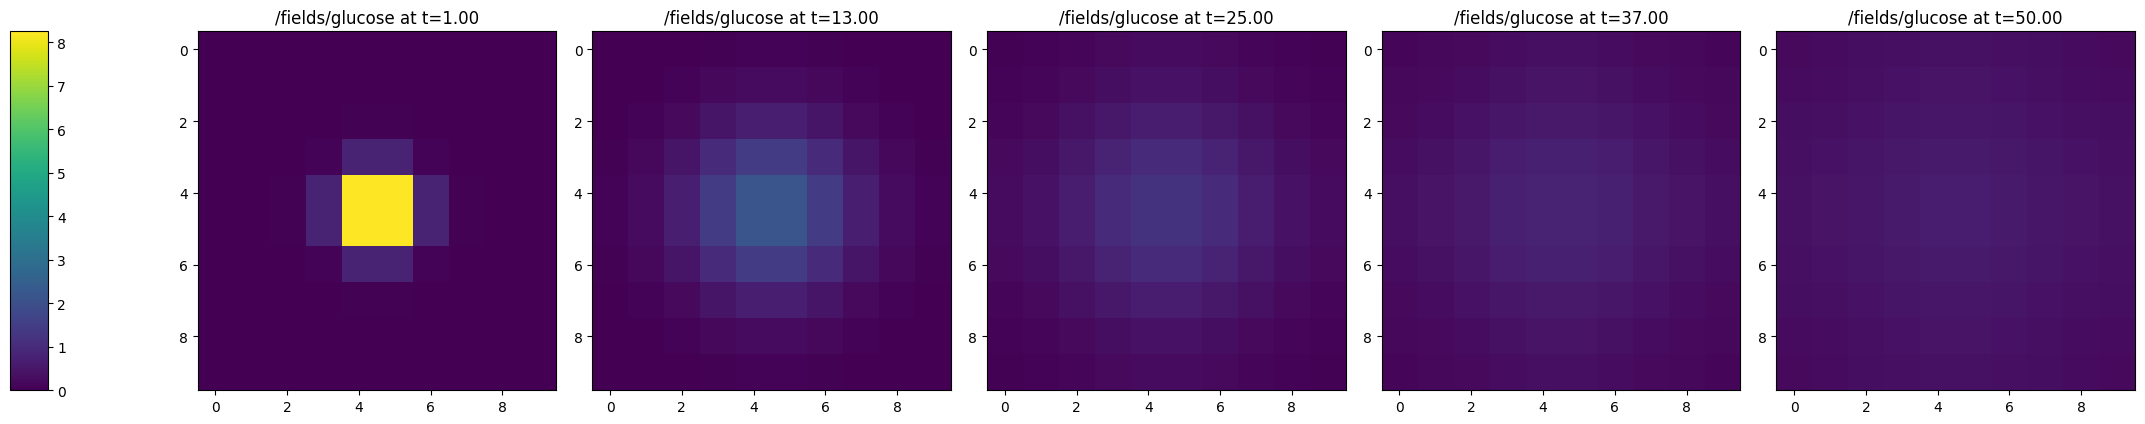

In [5]:
# Run the simulation
v_spatial.run(50)

# Plot snapshots at selected timepoints
fig = v_spatial.plot_snapshots(n_snapshots=5)
fig


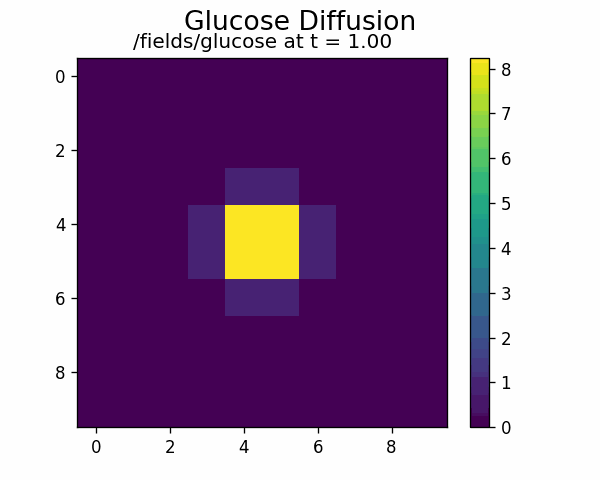

In [6]:
# Animate the field evolution as a GIF
v_spatial.show_video(skip_frames=5, title='Glucose Diffusion')